In [2]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd

In [3]:
QKE = pd.make_data_dictionary("../results/anvil/51-full_QKE.csv", "../results/anvil/51-full_QKE-eps.csv")
coherent = pd.make_data_dictionary("../results/coherent_only_run.csv", "../results/coherent_only_eps.csv")
thermal = pd.make_data_dictionary("../results/anvil/07-nu_nu_coll.csv", "../results/anvil/06-nu_e_coll-eps.csv")

In [4]:
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w'])

In [5]:
e_color = '#008185'
m_color = '#5CBE00'
index_plots = [15, 45]

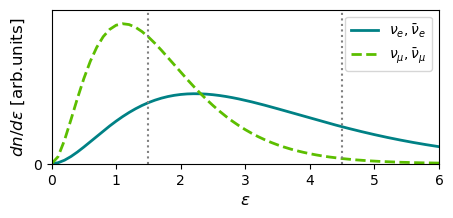

In [6]:
eps_max = 6

eps = QKE['eps']
fe = QKE['f'][pd.NU_E]
fm = QKE['f'][pd.NU_MU]
plt.figure(figsize=(5,2))
plt.plot(eps, eps**2 / (2 * np.pi**2) * fe[0,:], c=e_color, lw=2, label=r"$\nu_e, \bar\nu_e$")
plt.plot(eps, eps**2 / (2 * np.pi**2) * fm[0,:], c=m_color, lw=2, ls="--", label=r"$\nu_\mu, \bar\nu_\mu$")
plt.xlim(0, eps_max)
plt.ylim(0, max(np.max(eps**2 / (2 * np.pi**2) * fe[0,:]), np.max(eps**2 / (2 * np.pi**2) * fm[0,:]))*1.1)
plt.legend()

plt.xlabel(r"$\epsilon$", fontsize=12)
plt.ylabel(r"$dn/d\epsilon$ [arb.units]", fontsize=12)

plt.axvline(eps[index_plots[0]], c='0.50', ls=":")
plt.axvline(eps[index_plots[1]], c='0.50', ls=":")

plt.yticks([0])
plt.show()

[Text(0, 0, '0'), Text(4, 0, '4'), Text(8, 0, '8'), Text(12, 0, '12')]

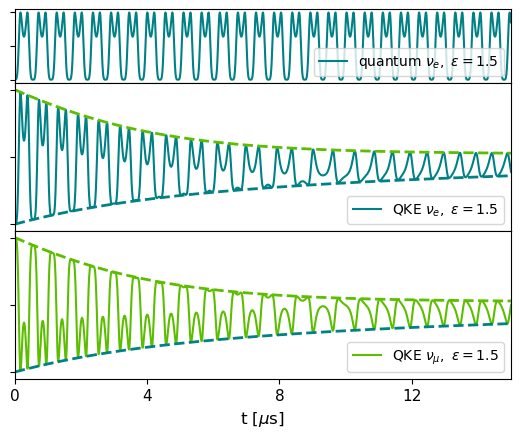

In [7]:
eps = QKE['eps']

fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, sharey=True, height_ratios=[0.2,0.4,0.4])
plt.subplots_adjust(hspace=0)

ax[0].plot(coherent['time'], coherent['f'][pd.NU_E][:, index_plots[0]] * eps[index_plots[0]]**2, c=e_color, label=r"quantum $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))

ax[1].plot(QKE['time'], QKE['f'][pd.NU_E][:, index_plots[0]] * eps[index_plots[0]]**2, c=e_color, label=r"QKE $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))
ax[1].plot(thermal['time'], thermal['f'][pd.NU_E][:,index_plots[0]] * eps[index_plots[0]]**2, c=e_color, ls="--", lw=2)
ax[1].plot(thermal['time'], thermal['f'][pd.NU_MU][:,index_plots[0]] * eps[index_plots[0]]**2, c=m_color, ls="--", lw=2)

ax[2].plot(QKE['time'], QKE['f'][pd.NU_MU][:,index_plots[0]] * eps[index_plots[0]]**2, c=m_color, label=r"QKE $\nu_\mu,~\epsilon={:.2}$".format(eps[index_plots[0]]))
ax[2].plot(thermal['time'], thermal['f'][pd.NU_E][:,index_plots[0]] * eps[index_plots[0]]**2, c=e_color, ls="--", lw=2)
ax[2].plot(thermal['time'], thermal['f'][pd.NU_MU][:,index_plots[0]] * eps[index_plots[0]]**2, c=m_color, ls="--", lw=2)

#ax[2].set_xlim(0,min(np.max(coherent['time']), np.max(QKE['time'])))
ax[2].set_xlim(0, 15)
ax[2].set_xlabel(r"t [$\mu$s]", fontsize=12)

#ax[0].set_yticks([np.min(coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2), np.max(coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2)])
#ax[0].set_yticks([])

ytickmin = np.min(coherent['f'][pd.NU_E][:,index_plots[0]]) * eps[index_plots[0]]**2
ytickmax = np.max(coherent['f'][pd.NU_E][:,index_plots[0]]) * eps[index_plots[0]]**2

ax[0].set_yticks([ytickmin, 0.5*(ytickmin+ytickmax), ytickmax])
ax[0].set_yticklabels(["","",""])
#fig.supylabel(r"$dn/d\epsilon$ for $\epsilon = 1.5$", fontsize=12)

ax[0].legend(loc='lower right')
ax[1].legend(loc='lower right')
ax[2].legend(loc='lower right')

ax[2].set_xticks([0, 4, 8, 12])
ax[2].set_xticklabels([0,4,8,12],fontsize=11)

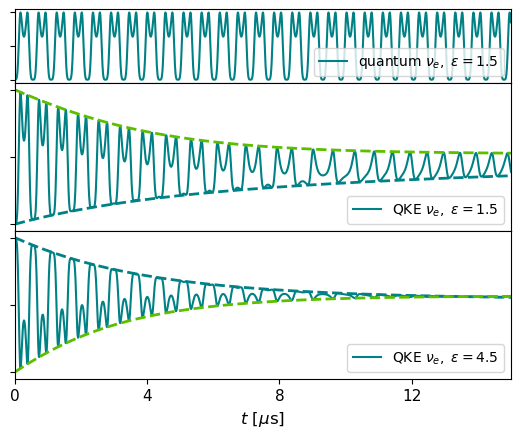

In [8]:
fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, height_ratios=[0.2,0.4,0.4])
plt.subplots_adjust(hspace=0)

eps = QKE['eps']

ax[0].plot(coherent['time'], coherent['f'][pd.NU_E][:,index_plots[0]]*eps[index_plots[0]]**2, c=e_color, label=r"quantum $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))

for i in range(2):
    ax[i+1].plot(QKE['time'], QKE['f'][pd.NU_E][:,index_plots[i]]*eps[index_plots[i]]**2, c=e_color, label=r"QKE $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[i]]))
    ax[i+1].plot(thermal['time'], thermal['f'][pd.NU_E][:,index_plots[i]]*eps[index_plots[i]]**2, ls="--", lw=2, c=e_color)
    ax[i+1].plot(thermal['time'], thermal['f'][pd.NU_MU][:,index_plots[i]]*eps[index_plots[i]]**2, ls="--", lw=2, c=m_color)

ax[0].set_xlim(0,15)
ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
ax[2].set_xticks([0, 4, 8, 12])
ax[2].set_xticklabels([0,4,8,12],fontsize=11)

for i in range(3):
    ytickmin = np.min(coherent['f'][pd.NU_E][:,index_plots[i//2]]) * eps[index_plots[i//2]]**2
    ytickmax = np.max(coherent['f'][pd.NU_E][:,index_plots[i//2]]) * eps[index_plots[i//2]]**2

    ax[i].set_yticks([ytickmin, 0.5*(ytickmin+ytickmax), ytickmax])
    ax[i].set_yticklabels(["","",""])
    ax[i].legend(loc='lower right')


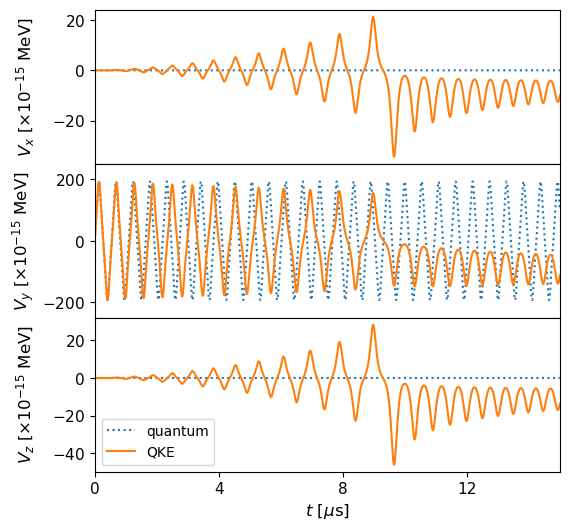

In [9]:
fig, ax = plt.subplots(figsize=(6,6), nrows=3, ncols=1, sharex=True)
plt.subplots_adjust(hspace=0)

V_coherent = pd.V_mat(coherent)
V_QKE = pd.V_mat(QKE)

for i in range(3):
    ax[i].plot(coherent['time'], V_coherent[i,:]*1e15, ls=":", label="quantum")
    ax[i].plot(QKE['time'], V_QKE[i,:]*1e15, label="QKE")
ax[0].set_xlim([0,15])

ax[0].set_ylabel(r"$V_x~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
ax[1].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
ax[2].set_ylabel(r"$V_z~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
ax[2].legend(loc='lower left')

fig.align_ylabels()
ax[2].set_xticks([0, 4, 8, 12])
ax[2].set_xticklabels([0,4,8,12],fontsize=11)

ax[0].set_yticks([-20,0,20], [r"$-20$",r"$0$",r"$20$"], fontsize=11)
ax[1].set_yticks([-200,0,200], [r"$-200$",r"$0$",r"$200$"], fontsize=11)
ax[1].set_ylim([-250,250])
ax[2].set_yticks([-40, -20,0,20], [r"$-40$",r"$-20$",r"$0$",r"$20$"], fontsize=11)

fig.align_ylabels()


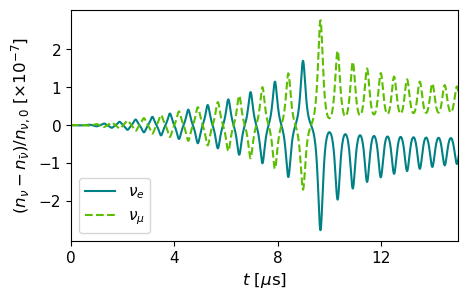

In [32]:
n = pd.num_density(QKE)

plt.figure(figsize=(5,3))
plt.plot(QKE['time'], (n[pd.NU_E,:]-n[pd.ANTI_NU_E,:])/n[pd.NU_E,0]*1e7, c=e_color, label=r"$\nu_e$")
plt.plot(QKE['time'], (n[pd.NU_MU,:]-n[pd.ANTI_NU_MU,:])/n[pd.NU_MU,0]*1e7, c=m_color, ls='--', label=r"$\nu_\mu$")
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$(n_\nu - n_{\bar\nu})/n_{\nu,0}~[\times 10^{-7}]$", fontsize=12)

plt.legend(loc='lower left', fontsize=11)

plt.xticks([0, 4, 8, 12], fontsize=11)
plt.yticks([-2,-1, 0,1,2], fontsize=11)
plt.xlim(0, 15)
plt.show()